In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#veri ön işleme
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


# Algoritmalar ( Kümeleme)
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

#Boyut indirme
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

#Değerlendirme Metrikleri

from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score


from scipy.cluster.hierarchy import dendrogram, linkage


plt.rcParams['figure.figsize'] = [16, 10]
plt.rcParams['font.size'] = 14
sns.set_style('whitegrid')
print('Herşey hazır')


Herşey hazır


In [4]:
data=pd.read_csv('/content/players.csv')
df=data.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   player_id      3150 non-null   int64 
 1   team_id        3150 non-null   int64 
 2   name           3150 non-null   object
 3   position       3150 non-null   object
 4   date_of_birth  3150 non-null   object
 5   nationality    3150 non-null   object
dtypes: int64(2), object(4)
memory usage: 147.8+ KB


In [5]:
df.tail()

,player_id,team_id,name,position,date_of_birth,nationality
3145,252843,576,Vignon Ouotro,Offence,2005-09-13,Ivory Coast
3146,252873,576,Tidiane Diallo,Offence,2006-05-28,France
3147,280,548,Guillermo Maripán,Defence,1994-05-06,Chile
3148,8913,546,Deiver Machado,Defence,1993-09-02,Colombia
3149,182199,521,Joffrey Bazie,Offence,2003-10-27,Burkina Faso



Model için Hazırlanan Özellikler:


,position,nationality_grouped,age
0,Goalkeeper,Brazil,33
1,Goalkeeper,England,41
2,Goalkeeper,Germany,34
3,Goalkeeper,England,21
4,Defence,Switzerland,31



✅ Veri ölçeklendirildi ve dönüştürüldü. Yeni boyut: (3150, 19)


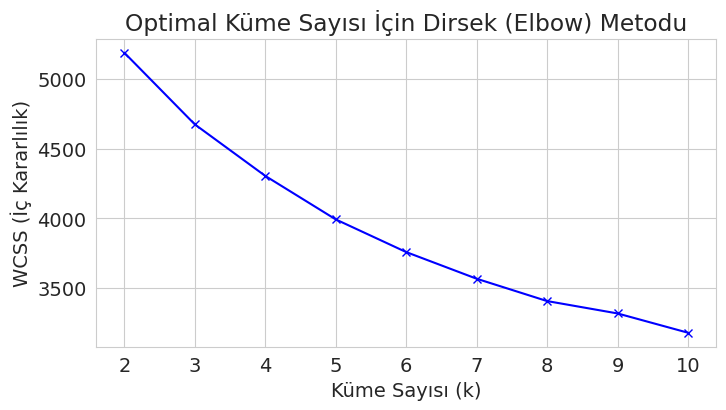


✅ K-Means, Hiyerarşik Kümeleme ve GMM modelleri başarıyla eğitildi.


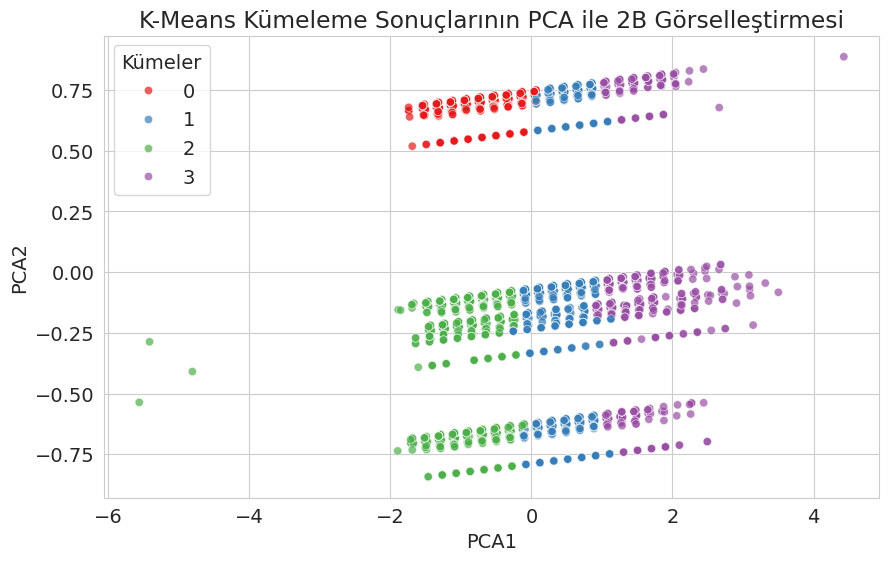


⚽ OLUŞAN KÜMELERİN ÖZET PROFİLLERİ (K-Means):

--- KÜME 0 ---
Oyuncu Sayısı: 580
Yaş Ortalaması: 23.6
En Çok Bulunan Mevki: Midfield
En Çok Bulunan Milliyet: Spain
Örnek Oyuncular:
          name position nationality  age
    Phil Foden Midfield     England   26
    Oscar Bobb Midfield      Norway   23
Micah Hamilton Midfield     England   23

--- KÜME 1 ---
Oyuncu Sayısı: 1081
Yaş Ortalaması: 29.5
En Çok Bulunan Mevki: Defence
En Çok Bulunan Milliyet: Spain
Örnek Oyuncular:
         name position nationality  age
Manuel Akanji  Defence Switzerland   31
  John Stones  Defence     England   32
   Nathan Aké  Defence Netherlands   31

--- KÜME 2 ---
Oyuncu Sayısı: 948
Yaş Ortalaması: 23.1
En Çok Bulunan Mevki: Defence
En Çok Bulunan Milliyet: Spain
Örnek Oyuncular:
          name   position nationality  age
    True Grant Goalkeeper     England   21
  Sergio Gómez    Defence       Spain   26
Joško Gvardiol    Defence     Croatia   24

--- KÜME 3 ---
Oyuncu Sayısı: 541
Yaş Ortalaması: 35

In [12]:
from datetime import datetime
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

df['date_of_birth'] = pd.to_datetime(df['date_of_birth'])
current_year = datetime.now().year
df['age'] = current_year - df['date_of_birth'].dt.year

# Kümeleme için kullanacağımız özellikleri seçelim (Mevki, Milliyet ve Yaş)
# (Çok fazla benzersiz milliyet varsa en sık geçen ilk 10-15 milliyeti tutmak mantıklı olabilir)
top_nationalities = df['nationality'].value_counts().index[:15]
df['nationality_grouped'] = df['nationality'].apply(lambda x: x if x in top_nationalities else 'Other')

features = ['position', 'nationality_grouped', 'age']
X = df[features]

print("\nModel için Hazırlanan Özellikler:")
display(X.head())

# ------------------------------------------------------------------------------
# ADIM 3: ENCODING VE SCALING (SAYISALLAŞTIRMA VE ÖLÇEKLENDİRME)
# ------------------------------------------------------------------------------
# Kategorik değişkenler (position, nationality) için OneHotEncoder, sayısal (age) için StandardScaler
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), ['position', 'nationality_grouped']),
        ('num', StandardScaler(), ['age'])
    ])

X_processed = preprocessor.fit_transform(X)
print(f"\n✅ Veri ölçeklendirildi ve dönüştürüldü. Yeni boyut: {X_processed.shape}")

# ------------------------------------------------------------------------------
# ADIM 4: K-MEANS VE ELBOW (DİRSEK) METODU İLE OPTİMAL KÜME SAYISI
# ------------------------------------------------------------------------------
wcss = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_processed)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, 'bx-')
plt.xlabel('Küme Sayısı (k)')
plt.ylabel('WCSS (İç Kararlılık)')
plt.title('Optimal Küme Sayısı İçin Dirsek (Elbow) Metodu')
plt.show()

# Örnek olarak 4 kümeye ayıralım (İsterseniz grafiğe göre bu sayıyı değiştirebilirsiniz)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_transform(X_processed).argmin(axis=1) # ya da direkt `.labels_`

# ------------------------------------------------------------------------------
# ADIM 5: DİĞER ALGORİTMALARIN UYGULANMASI (Karşılaştırma İçin)
# ------------------------------------------------------------------------------
# 1. Hierarchical Clustering (Hiyerarşik Kümeleme)
hc = AgglomerativeClustering(n_clusters=optimal_k)
df['HC_Cluster'] = hc.fit_predict(X_processed)

# 2. Gaussian Mixture Models (GMM)
gmm = GaussianMixture(n_components=optimal_k, random_state=42)
df['GMM_Cluster'] = gmm.fit_predict(X_processed)

print("\n✅ K-Means, Hiyerarşik Kümeleme ve GMM modelleri başarıyla eğitildi.")

# ------------------------------------------------------------------------------
# ADIM 6: BOYUT İNDİRGEME VE GÖRSELLEŞTİRME (PCA & t-SNE)
# ------------------------------------------------------------------------------
# Çok boyutlu veriyi 2 boyuta indirgeyip grafik üzerinde kümeleri görelim
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='KMeans_Cluster', data=df, palette='Set1', alpha=0.7)
plt.title('K-Means Kümeleme Sonuçlarının PCA ile 2B Görselleştirmesi')
plt.legend(title='Kümeler')
plt.show()

# ------------------------------------------------------------------------------
# ADIM 7: KÜME PROFİLLERİNİN VE SONUÇLARIN ANALİZİ
# ------------------------------------------------------------------------------
print("\n⚽ OLUŞAN KÜMELERİN ÖZET PROFİLLERİ (K-Means):")
for i in range(optimal_k):
    cluster_data = df[df['KMeans_Cluster'] == i]
    print(f"\n--- KÜME {i} ---")
    print(f"Oyuncu Sayısı: {len(cluster_data)}")
    print(f"Yaş Ortalaması: {cluster_data['age'].mean():.1f}")
    print(f"En Çok Bulunan Mevki: {cluster_data['position'].mode()[0]}")
    print(f"En Çok Bulunan Milliyet: {cluster_data['nationality'].mode()[0]}")
    print("Örnek Oyuncular:")
    print(cluster_data[['name', 'position', 'nationality', 'age']].head(3).to_string(index=False))

### Hiyerarşik Kümeleme (HC) Sonuçlarının PCA ile Görselleştirmesi

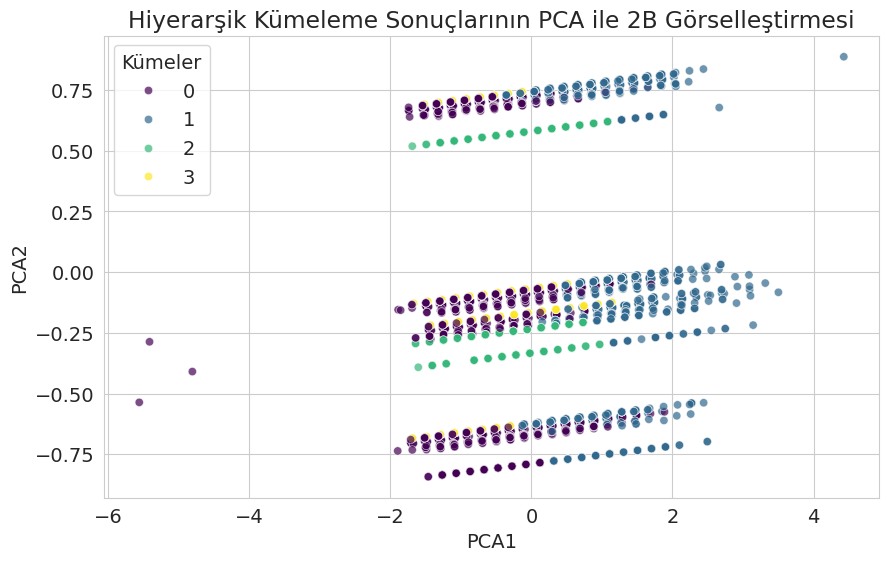

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='HC_Cluster', data=df, palette='viridis', alpha=0.7)
plt.title('Hiyerarşik Kümeleme Sonuçlarının PCA ile 2B Görselleştirmesi')
plt.legend(title='Kümeler')
plt.show()

### Gaussian Mixture Models (GMM) Sonuçlarının PCA ile Görselleştirmesi

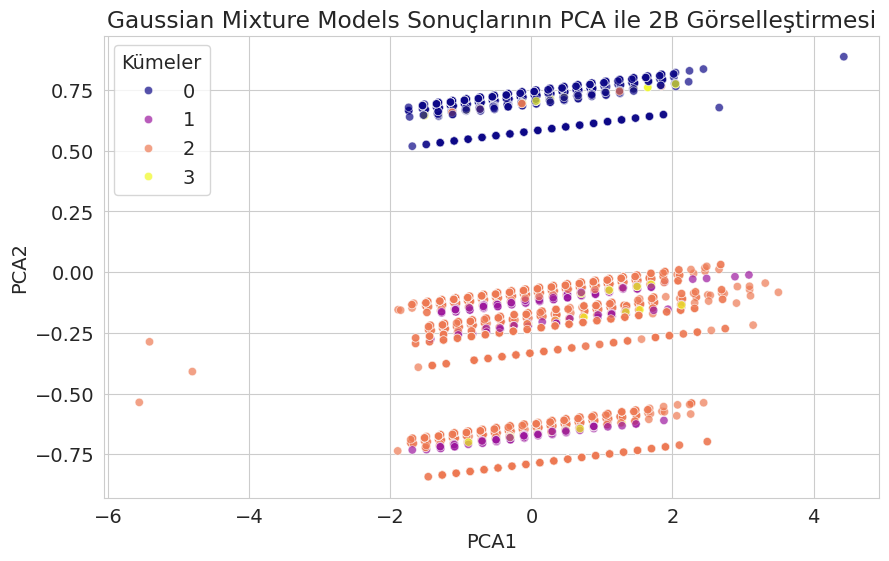

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='GMM_Cluster', data=df, palette='plasma', alpha=0.7)
plt.title('Gaussian Mixture Models Sonuçlarının PCA ile 2B Görselleştirmesi')
plt.legend(title='Kümeler')
plt.show()

### DBSCAN Kümeleme Algoritmasının Uygulanması ve Görselleştirilmesi

In [16]:
# 3. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
# DBSCAN için uygun parametreleri (eps, min_samples) belirlemek önemlidir.
# İlk deneme için varsayılan değerler kullanıyoruz.
# Gerçek bir senaryoda bu parametreler genellikle K-Distance grafiği veya domain bilgisi ile bulunur.
dbsc = DBSCAN(eps=0.5, min_samples=5) # Bu değerleri veri setinize göre ayarlamanız gerekebilir
df['DBSCAN_Cluster'] = dbsc.fit_predict(X_processed)

print("\n✅ DBSCAN modeli başarıyla eğitildi.")


✅ DBSCAN modeli başarıyla eğitildi.


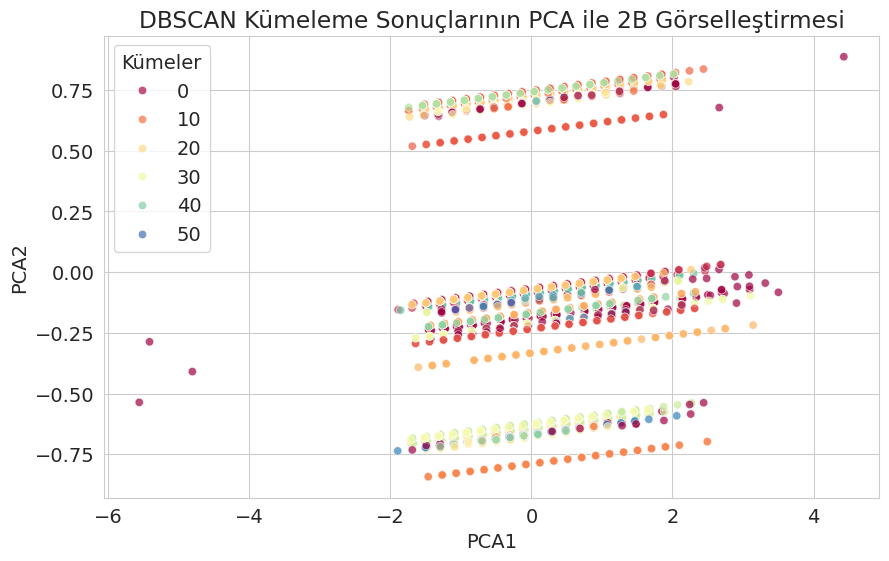

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='DBSCAN_Cluster', data=df, palette='Spectral', alpha=0.7)
plt.title('DBSCAN Kümeleme Sonuçlarının PCA ile 2B Görselleştirmesi')
plt.legend(title='Kümeler')
plt.show()

### t-SNE ile Boyut İndirgeme ve Kümelerin Görselleştirmesi

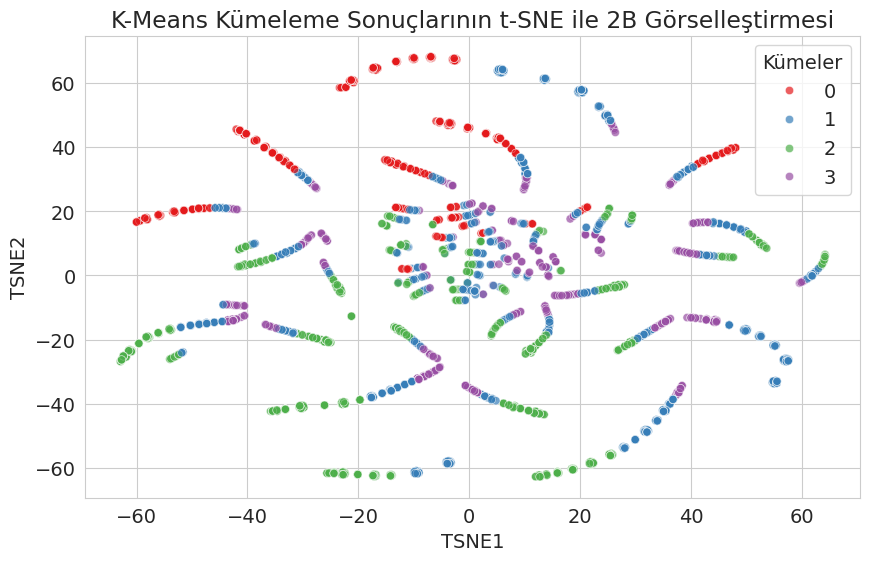


✅ t-SNE boyut indirgeme ve görselleştirme başarıyla tamamlandı.


In [18]:
# t-SNE (t-Distributed Stochastic Neighbor Embedding) - Görselleştirme
# t-SNE, özellikle yüksek boyutlu verileri görselleştirmek için kullanılır.
# Hesaplama yoğundur, bu yüzden bazen PCA sonrası uygulanabilir.
# `n_components` genellikle 2 veya 3 olarak ayarlanır.

ts = TSNE(n_components=2, random_state=42, perplexity=30) # Perplexity değeri veri setine göre ayarlanmalıdır.
X_tsne = ts.fit_transform(X_processed)
df['TSNE1'] = X_tsne[:, 0]
df['TSNE2'] = X_tsne[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='KMeans_Cluster', data=df, palette='Set1', alpha=0.7)
plt.title('K-Means Kümeleme Sonuçlarının t-SNE ile 2B Görselleştirmesi')
plt.legend(title='Kümeler')
plt.show()

print("\n✅ t-SNE boyut indirgeme ve görselleştirme başarıyla tamamlandı.")